# Potomac Sewage Spill (Jan 2026) — Event Overlay Demo

A first-look visualization of the [`OlmoEarth-v1-Potomac-Sewage-Spill-2026`](https://huggingface.co/datasets/BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026) reference dataset for the January 19, 2026 Potomac Interceptor sewage spill: 846 daily discharge observations across the Potomac corridor, anchored to a 4-phase event timeline.

## What You'll Learn

- How to pull the daily flow data and the operational event log from Hugging Face
- The 4-phase event timeline and how it partitions the observation window
- Daily discharge per gauge with the event phases overlaid as background shading
- The spatial layout of the USGS monitoring gauges along the corridor

## Why

When triaging a discharge event, Civil & Environmental Engineering practitioners need to see at a glance *where* the spill happened, *when* each phase began and ended, and *which* gauges saw measurable change. This demo answers all three in under a minute.

## Requirements

- Python 3.11
- `pandas`, `matplotlib`, `datasets`, `huggingface_hub` (see `requirements.txt`)
- ~1 minute runtime, no GPU required

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from datasets import load_dataset
from huggingface_hub import hf_hub_download

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

## 1. Load the daily flow data

Pull the main parquet from Hugging Face — 846 rows of daily discharge spanning Dec 1 2025 → Mar 31 2026.

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026")
df = ds["train"].to_pandas()
df['date'] = pd.to_datetime(df['date'])
print(f"Rows: {len(df):,}  |  Stations: {df['site_no'].nunique()}  |  Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
df.head()

README.md: 0.00B [00:00, ?B/s]

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Frank\.cache\huggingface\hub\datasets--BAIGroup--OlmoEarth-v1-Potomac-Sewage-Spill-2026. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data.parquet:   0%|          | 0.00/11.1k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/846 [00:00<?, ? examples/s]

Rows: 846  |  Stations: 7  |  Date range: 2025-12-01 -> 2026-03-31


,site_no,date,discharge_cfs,role,phase,name,latitude,longitude
0,01638500,2025-12-01,1830.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111
1,01638500,2025-12-02,1870.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111
2,01638500,2025-12-03,1990.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111
3,01638500,2025-12-04,1960.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111
4,01638500,2025-12-05,1910.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111


## 2. The 4-phase event timeline

The dataset divides the observation window into four phases marking the lifecycle of the spill event: pre-spill baseline, active untreated release, bypass period (reduced ongoing impact), and post-recovery.

In [3]:
phases = (
    df.groupby('phase', observed=True)['date']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'start', 'max': 'end', 'count': 'station_days'})
    .reindex(['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery'])
)
phases

,start,end,station_days
phase,,,
pre_spill_baseline,2025-12-01,2026-01-18,343
active_release,2026-01-19,2026-01-24,42
bypass_period,2026-01-25,2026-03-14,342
post_recovery,2026-03-15,2026-03-31,119


## 3. Daily discharge with event phases overlaid

One panel per gauge. Background shading marks the four event phases — making it immediately clear which gauges saw flow signatures during the active release vs the bypass period.

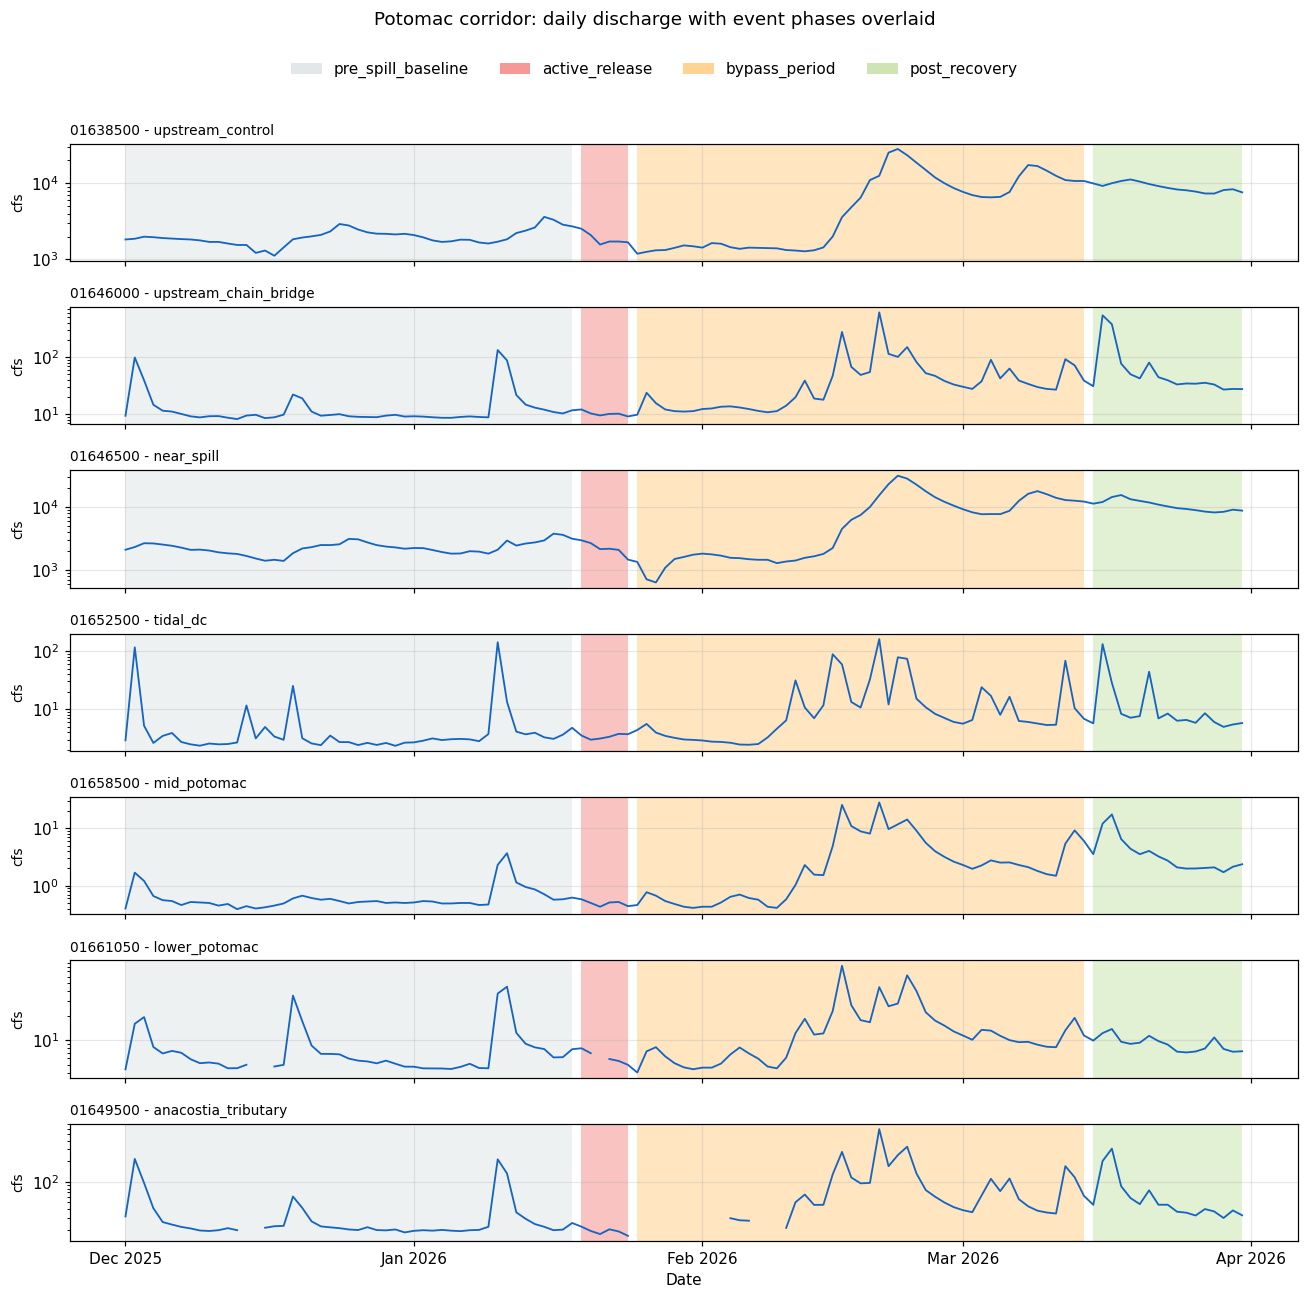

In [4]:
PHASE_COLORS = {
    'pre_spill_baseline': '#cfd8dc',
    'active_release':     '#ef5350',
    'bypass_period':      '#ffb74d',
    'post_recovery':      '#aed581',
}
PHASE_ORDER = ['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery']

phase_bounds = {p: (phases.loc[p, 'start'], phases.loc[p, 'end'])
                for p in PHASE_ORDER if p in phases.index and pd.notna(phases.loc[p, 'start'])}

gauges = (
    df.groupby('site_no')
    .agg(name=('name', 'first'), role=('role', 'first'), n=('discharge_cfs', 'count'))
    .sort_values('n', ascending=False)
)

n_panels = len(gauges)
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 1.6 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

for ax, (sno, row) in zip(axes, gauges.iterrows()):
    s = df[df['site_no'] == sno].sort_values('date')
    for ph, (a, b) in phase_bounds.items():
        ax.axvspan(a, b, color=PHASE_COLORS[ph], alpha=0.35, lw=0)
    ax.plot(s['date'], s['discharge_cfs'], lw=1.2, color='#1565c0')
    ax.set_yscale('log')
    ax.set_ylabel("cfs", fontsize=9)
    ax.set_title(f"{sno} - {row['role']}", fontsize=9, loc='left')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend_handles = [Patch(facecolor=PHASE_COLORS[p], alpha=0.6, label=p) for p in PHASE_ORDER if p in phase_bounds]
fig.legend(handles=legend_handles, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Potomac corridor: daily discharge with event phases overlaid", y=1.05)
plt.tight_layout()
plt.show()

## 4. Where are the gauges?

The USGS gauges run from upstream of the spill site (Point of Rocks, MD) down through the tidal DC reach toward the lower Potomac.

 site_no                                                         name                  role  latitude  longitude
01638500                          Potomac River at Point of Rocks, MD      upstream_control 39.273583 -77.543111
01646000             Potomac River near Washington, DC (Chain Bridge) upstream_chain_bridge 38.975943 -77.245814
01646500 Potomac River near Washington, DC, Little Falls Pump Station            near_spill 38.949778 -77.127639
01649500            Northeast Branch Anacostia River at Riverdale, MD   anacostia_tributary 38.960250 -76.925972
01652500              Potomac River at Wisconsin Ave., Washington, DC              tidal_dc 38.843333 -77.085861
01658500                  South Fork Quantico Creek near Triangle, VA           mid_potomac 38.587343 -77.428596
01661050                         St. Clements Creek near Clements, MD         lower_potomac 38.333306 -76.725000


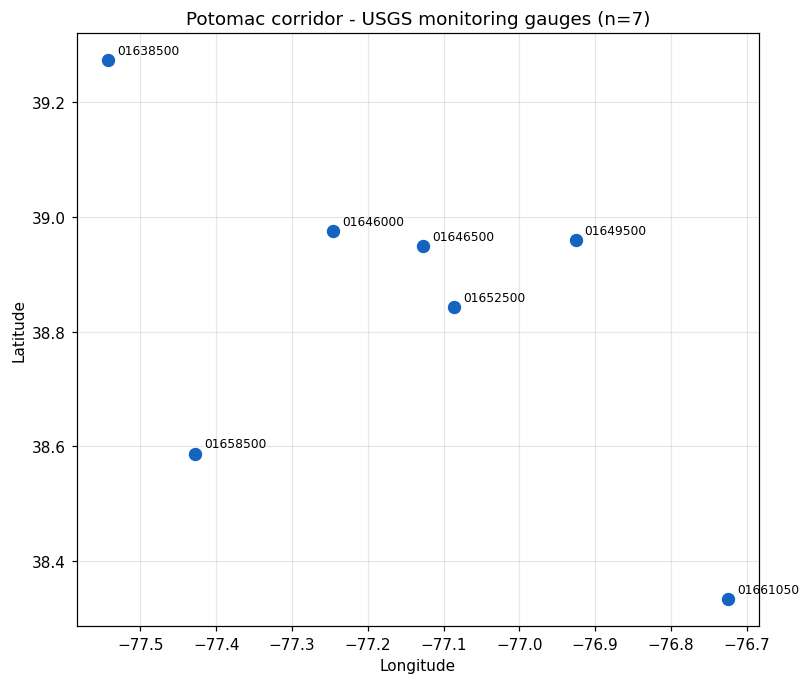

In [5]:
stn_meta = (
    df.drop_duplicates('site_no')[['site_no', 'name', 'role', 'latitude', 'longitude']]
    .reset_index(drop=True)
)
print(stn_meta.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 7))
for _, r in stn_meta.iterrows():
    ax.scatter(r['longitude'], r['latitude'], s=90, color='#1565c0',
               edgecolor='white', linewidth=0.7, zorder=3)
    ax.annotate(r['site_no'], (r['longitude'], r['latitude']),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Potomac corridor - USGS monitoring gauges (n={len(stn_meta)})")
ax.grid(alpha=0.3)
plt.show()

## 5. Event log preview

The companion `event_log.csv` records 71 operational events from DC Water and partner agencies — useful context when interpreting flow anomalies and downstream impacts.

In [6]:
event_log_path = hf_hub_download(
    repo_id="BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026",
    filename="event_log.csv",
    repo_type="dataset",
)
events = pd.read_csv(event_log_path, parse_dates=['date'])
print(f"Total events: {len(events)}  |  Date range: {events['date'].min().date()} -> {events['date'].max().date()}")
print()
print("Event type counts:")
print(events['event_type'].value_counts().to_string())
events.head(8)

event_log.csv: 0.00B [00:00, ?B/s]

Total events: 71  |  Date range: 2026-01-19 -> 2026-04-28

Event type counts:
event_type
cleanup           20
containment       14
repair            12
excavation         6
monitoring         5
infrastructure     5
assessment         5
weather            3
incident           1


,date,event_type,description,phase,source_url
0,2026-01-19,incident,DC Water investigating sanitary sewer overflow...,active_release,https://www.dcwater.com/about-dc-water/media/p...
1,2026-01-20,containment,Work to contain and create bypass system for s...,active_release,https://www.dcwater.com/about-dc-water/media/p...
2,2026-01-21,containment,Advancing work on bypass to contain sewer over...,active_release,https://www.dcwater.com/about-dc-water/media/p...
3,2026-01-22,containment,Working to install bypass pumps; progress on c...,active_release,https://www.dcwater.com/about-dc-water/media/p...
4,2026-01-23,containment,Pumps in place; reinforcing receiving section ...,active_release,https://www.dcwater.com/about-dc-water/media/p...
5,2026-01-24,containment,Bypass activated to contain wastewater overflo...,active_release,https://www.dcwater.com/about-dc-water/media/p...
6,2026-01-25,excavation,Work underway to drain remaining wastewater fo...,bypass_period,https://www.dcwater.com/about-dc-water/media/p...
7,2026-01-26,containment,Sewer overflow significantly reduced; weather ...,bypass_period,https://www.dcwater.com/about-dc-water/media/p...


## What's Next

- **`02_data_prep_reproduce.ipynb`** — rebuild the dataset from raw USGS NWIS pulls and agency reporting.
- **`03_tutorial_plume_context.ipynb`** — interpret discharge signals in light of the event timeline and AOI corridors.
- **`04_analysis_event_log.ipynb`** — synthesize the 71-event operational log across the 4 phases.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*